Gen 0 Best: 301.28343997763574
Gen 20 Best: 220.25058620401182
Gen 40 Best: 220.25058620401182
Gen 60 Best: 220.25058620401182
Gen 80 Best: 220.25058620401182
Gen 100 Best: 220.25058620401182
Gen 120 Best: 220.25058620401182
Gen 140 Best: 220.25058620401182
Gen 160 Best: 220.25058620401182
Gen 180 Best: 220.25058620401182
Gen 200 Best: 220.25058620401182
Gen 220 Best: 220.25058620401182
Gen 240 Best: 220.25058620401182
Gen 260 Best: 220.25058620401182
Gen 280 Best: 220.25058620401182
Gen 300 Best: 220.25058620401182
Gen 320 Best: 220.25058620401182
Gen 340 Best: 220.25058620401182
Gen 360 Best: 220.25058620401182
Gen 380 Best: 220.25058620401182

BEST COST: 220.25058620401182
ROUTE: [9, 7, 13, 5, 2, 14, 3, 4, 1, 10, 12, 6, 11, 15, 8]


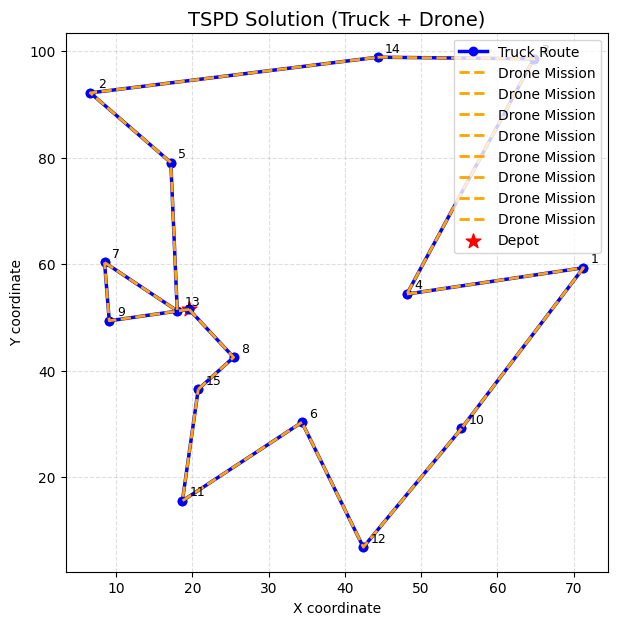

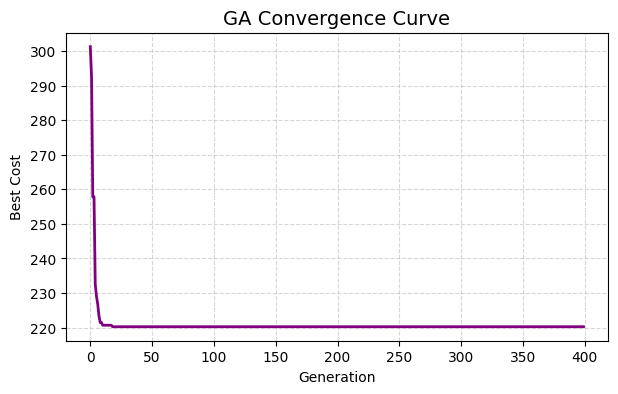

In [10]:
import random
import math
import matplotlib.pyplot as plt

# ==========================================================
# PARAMETERS
# ==========================================================

NUM_CUSTOMERS = 15
POP_SIZE = 160
GENERATIONS = 400

CROSSOVER_RATE = 0.9
BASE_MUTATION = 0.12
ELITE_SIZE = 2

TRUCK_SPEED = 1.0
DRONE_SPEED = 1.7
DRONE_ENDURANCE = 80

STAGNATION_LIMIT = 60


# ==========================================================
# NODE GENERATION
# ==========================================================

def generate_nodes(n):

    nodes = []

    for _ in range(n+1):
        x = random.uniform(0,100)
        y = random.uniform(0,100)

        nodes.append((x,y))

    return nodes


# ==========================================================
# DISTANCE MATRIX
# ==========================================================

def euclidean(a,b):

    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)


def build_distance_matrix(nodes):

    n = len(nodes)

    matrix = [[0]*n for _ in range(n)]

    for i in range(n):
        for j in range(n):

            matrix[i][j] = euclidean(nodes[i],nodes[j])

    return matrix


# ==========================================================
# INDIVIDUAL
# ==========================================================

class Individual:

    def __init__(self,route):

        self.route = route
        self.cost = None
        self.drone_missions = []


# ==========================================================
# POPULATION INIT
# ==========================================================

def random_route(n):

    r = list(range(1,n+1))
    random.shuffle(r)

    return r


def init_population():

    return [Individual(random_route(NUM_CUSTOMERS))
            for _ in range(POP_SIZE)]


# ==========================================================
# TSPD DECODER
# ==========================================================

def decode_tspd(ind,dist):

    route = [0] + ind.route + [0]

    missions = []

    i = 0
    total = 0

    while i < len(route)-1:

        if i+2 < len(route):

            launch = route[i]
            drone = route[i+1]
            rendez = route[i+2]

            drone_dist = dist[launch][drone] + dist[drone][rendez]

            if drone_dist <= DRONE_ENDURANCE:

                truck_time = dist[launch][rendez] / TRUCK_SPEED
                drone_time = drone_dist / DRONE_SPEED

                total += max(truck_time,drone_time)

                missions.append((launch,drone,rendez))

                i += 2
                continue

        a = route[i]
        b = route[i+1]

        total += dist[a][b] / TRUCK_SPEED

        i += 1

    ind.cost = total
    ind.drone_missions = missions


def evaluate_population(pop,dist):

    for ind in pop:
        decode_tspd(ind,dist)


# ==========================================================
# SELECTION
# ==========================================================

def tournament_selection(pop,k=5):

    cand = random.sample(pop,k)

    cand.sort(key=lambda x:x.cost)

    return Individual(cand[0].route[:])


# ==========================================================
# CROSSOVER
# ==========================================================

def order_crossover(p1,p2):

    if random.random() > CROSSOVER_RATE:
        return Individual(p1.route[:])

    size = len(p1.route)

    a,b = sorted(random.sample(range(size),2))

    child = [None]*size

    child[a:b] = p1.route[a:b]

    fill = [x for x in p2.route if x not in child]

    idx = 0

    for i in range(size):

        if child[i] is None:
            child[i] = fill[idx]
            idx += 1

    return Individual(child)


# ==========================================================
# MUTATION
# ==========================================================

def mutate(ind,rate):

    if random.random() < rate:

        i,j = random.sample(range(len(ind.route)),2)

        ind.route[i],ind.route[j] = ind.route[j],ind.route[i]


# ==========================================================
# LIMITED 2OPT
# ==========================================================

def two_opt_limited(route,dist):

    best = route[:]

    for _ in range(30):

        i,j = sorted(random.sample(range(len(route)),2))

        if j-i < 2:
            continue

        new = best[:]
        new[i:j] = reversed(new[i:j])

        if tsp_cost(new,dist) < tsp_cost(best,dist):

            best = new

    return best


def tsp_cost(route,dist):

    r = [0]+route+[0]

    total = 0

    for i in range(len(r)-1):

        total += dist[r[i]][r[i+1]]

    return total


# ==========================================================
# ELITISM
# ==========================================================

def elitism(pop,dist):

    for ind in pop:
        if ind.cost is None:
            decode_tspd(ind,dist)

    pop.sort(key=lambda x:x.cost)

    elites = []

    for i in range(ELITE_SIZE):

        e = Individual(pop[i].route[:])
        e.cost = pop[i].cost
        e.drone_missions = pop[i].drone_missions[:]

        elites.append(e)

    return elites


# ==========================================================
# DIVERSITY INJECTION
# ==========================================================

def inject_diversity(pop):

    for _ in range(int(POP_SIZE*0.1)):

        idx = random.randint(ELITE_SIZE,POP_SIZE-1)

        pop[idx] = Individual(random_route(NUM_CUSTOMERS))


# ==========================================================
# GA
# ==========================================================

def GA(nodes):

    dist = build_distance_matrix(nodes)

    population = init_population()

    evaluate_population(population,dist)

    best = None
    history = []

    stagnation = 0

    for g in range(GENERATIONS):

        mutation_rate = BASE_MUTATION * (1 + stagnation/50)

        new_pop = elitism(population,dict)

        while len(new_pop) < POP_SIZE:

            p1 = tournament_selection(population)
            p2 = tournament_selection(population)

            child = order_crossover(p1,p2)

            mutate(child,mutation_rate)

            if random.random() < 0.4:
                child.route = two_opt_limited(child.route,dist)

            decode_tspd(child,dist)

            new_pop.append(child)

        population = new_pop

        evaluate_population(population,dist)

        population.sort(key=lambda x:x.cost)

        if best is None or population[0].cost < best.cost:

            best = population[0]
            stagnation = 0

        else:

            stagnation += 1

        history.append(best.cost)

        if stagnation > STAGNATION_LIMIT:

            inject_diversity(population)
            evaluate_population(population,dist)
            stagnation = 0

        if g % 20 == 0:

            print("Gen",g,"Best:",best.cost)

    return best,history


# ==========================================================
# VISUALIZATION
# ==========================================================

def plot_solution(nodes, best):

    plt.figure(figsize=(7,7))

    route = [0] + best.route + [0]

    # =========================
    # Draw truck route
    # =========================
    truck_x = [nodes[i][0] for i in route]
    truck_y = [nodes[i][1] for i in route]

    plt.plot(truck_x, truck_y,
             color="blue",
             linewidth=2.5,
             marker="o",
             label="Truck Route")

    # =========================
    # Draw drone missions
    # =========================
    for m in best.drone_missions:

        launch, drone, rendez = m

        x = [nodes[launch][0], nodes[drone][0], nodes[rendez][0]]
        y = [nodes[launch][1], nodes[drone][1], nodes[rendez][1]]

        plt.plot(x, y,
                 color="orange",
                 linestyle="--",
                 linewidth=2,
                 label="Drone Mission")

    # =========================
    # Draw depot
    # =========================
    depot_x, depot_y = nodes[0]

    plt.scatter(depot_x, depot_y,
                color="red",
                s=120,
                marker="*",
                label="Depot")

    # =========================
    # Draw customers
    # =========================
    for i in range(1, len(nodes)):

        x, y = nodes[i]

        plt.scatter(x, y, color="blue")

        plt.text(x+1, y+1, str(i),
                 fontsize=9)

    # =========================
    # Styling
    # =========================
    plt.title("TSPD Solution (Truck + Drone)", fontsize=14)

    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")

    plt.grid(True, linestyle="--", alpha=0.4)

    plt.legend()

    plt.show()

def plot_convergence(history):

    plt.figure(figsize=(7,4))

    generations = list(range(len(history)))

    plt.plot(generations, history,
             color="purple",
             linewidth=2)

    plt.title("GA Convergence Curve", fontsize=14)

    plt.xlabel("Generation")
    plt.ylabel("Best Cost")

    plt.grid(True, linestyle="--", alpha=0.5)

    plt.show()
# ==========================================================
# RUN
# ==========================================================

if __name__ == "__main__":

    nodes = generate_nodes(NUM_CUSTOMERS)

    best,history = GA(nodes)

    print("\nBEST COST:",best.cost)
    print("ROUTE:",best.route)

    plot_solution(nodes,best)
    plot_convergence(history)